# rect → sinc — 기하적 유도

`rect_W(t)`의 푸리에 변환이 왜 `2·sin(ωW)/ω = 2W·sinc(ωW/π)`인지 그림으로 직접 본다.

$$
\text{rect}_W(t) = \begin{cases} 1, & |t| < W \\ 0, & \text{otherwise} \end{cases}, \quad
X(j\omega) = \int_{-W}^{W} e^{-j\omega t}\, dt
$$

이 노트북에서 **W = 2**로 고정. 적분 구간 양 끝점에서 `e^(-jωt)`의 각도는 $+\omega W$와 $-\omega W$로, **총 회전각**은 $\theta_{\text{total}} = 2\omega W = 4\omega$.

피적분 함수는 단위벡터(크기 1)니까, 적분 = 단위원 위 호 한 조각의 *벡터합 × dt*. 이걸 두 단계로 나눠 본다.

**Phase 1**: ω가 작아 호가 한 바퀴를 못 도는 상태. *호의 chord*가 곧 적분값이고, chord 길이 = $2\sin(\omega W)/\omega$ — 여기서 sin 항이 나옴.

**Phase 2**: 잔여각 $\theta_\text{res} = \pi/6$을 고정하고 ω를 키움. 사라지는 주기 묶음이 늘어나는데 잔여 호의 모양은 같음. 같은 호를 만든 *시간*이 1/ω로 줄었으니 적분값도 1/ω로 줄어듦 — 1/ω 항이 여기서 나옴.

**Phase 3**: 두 항이 합쳐져 sinc. ftvis.SpectrumPlot으로 X(jω) 전체 모양 확인.

In [27]:
import numpy as np
import plotly.graph_objects as go
from ftvis import signals, FourierAnalyzer, SpectrumPlot

# 통일 — 다른 데모와 같은 dark 테마
_BG = "#0d1117"
_FG = "#e6edf3"
_GRID = "#30363d"
_AXIS = "#7d8590"
_GREEN = "#7ec699"   # 잔여 호 (강조)
_BLUE = "#58a6ff"    # chord
_ORANGE = "#ffa657"  # 누적 끝점 / chord 마커
_DIM = "#3a4452"     # 사라지는 주기 묶음

W = 2.0
print(f'W = {W}  →  rect_W(t) = 1 for |t| < {W}')
print(f'X(jω) = ∫_{{-W}}^{{W}} e^(-jωt) dt = 2·sin(ωW)/ω')

W = 2.0  →  rect_W(t) = 1 for |t| < 2.0
X(jω) = ∫_{-W}^{W} e^(-jωt) dt = 2·sin(ωW)/ω


## Phase 1 — `sin(ωW)` 항이 어디서 나오는가

ω를 작게 잡아 호가 한 바퀴를 못 채우게 한다. 그러면 적분 구간 [-W, W]에서 단위벡터들이 단위원 위에 호 한 조각을 만든다.

호의 시작 각도는 $+\omega W$ (t = -W에서 e^(-jω·(-W)) = e^(+jωW)), 끝 각도는 $-\omega W$. 호 위 단위벡터들의 *합*은 호의 양 끝을 잇는 **chord**. chord 길이는 단순 기하로:

$$\text{chord} = 2\sin(\omega W)$$

여기에 dt 가중치를 곱하고 N개 점으로 나눴으니 합은 $\frac{2W}{N}\cdot$ (이산 합). N→∞ 극한으로:

$$X(j\omega) = \int_{-W}^{W} e^{-j\omega t}\, dt = \frac{2\sin(\omega W)}{\omega}$$

ω를 작게 잡아 잔여각 θ = ωW가 **π/6, π/3, π/2**가 되는 세 경우를 나란히 본다. sin(θ)가 0.5, 0.866, 1로 자연스럽게 변하는 게 그림에서 직접 보일 것.

In [28]:
def make_unit_arrows(omega: float, W: float, n_points: int = 60):
    """t ∈ [-W, W]에서 균등 분할한 단위벡터들의 머리잇기 좌표.

    Returns
    -------
    arrows : (n+1,) complex
        Δt = 2W/n,  arrow_k = e^(-jω·t_k) · Δt,  t_k = -W + k·Δt
    cum : (n+1,) complex
        머리잇기 누적합. cum[0] = 0,  cum[-1] ≈ X(jω).
    chord_endpoints : (2,) complex
        호의 양 끝점 (단위원 위 두 점). 시각적으로 chord를 그릴 때 사용.
    """
    dt = 2 * W / n_points
    t = -W + np.arange(n_points) * dt + dt / 2  # midpoint rule (정확도 ↑)
    arrows = np.exp(-1j * omega * t) * dt
    cum = np.concatenate([[0+0j], np.cumsum(arrows)])
    # chord는 단위벡터 끝점(원 위)을 잇는 선. 적분값과 모양은 같지만 dt 인자 빠진 단위원 위 표시용.
    chord_endpoints = np.array([np.exp(-1j * omega * (-W)),
                                 np.exp(-1j * omega * W)])
    return arrows, cum, chord_endpoints


def make_unit_circle_trace(color=_AXIS, width=1):
    """단위원 점선 trace."""
    th = np.linspace(0, 2*np.pi, 200)
    return go.Scatter(x=np.cos(th), y=np.sin(th),
                      mode='lines',
                      line=dict(color=color, width=width, dash='dot'),
                      hoverinfo='skip', showlegend=False)


def style_panel(fig, title, xrange, yrange):
    """공통 패널 스타일."""
    fig.update_layout(
        paper_bgcolor=_BG, plot_bgcolor=_BG,
        font=dict(color=_FG, size=11),
        margin=dict(l=10, r=10, t=40, b=10),
        showlegend=False,
        title=dict(text=title, x=0.5, xanchor='center'),
        xaxis=dict(range=xrange, gridcolor=_GRID, zerolinecolor=_AXIS,
                   color=_FG, title='Re', scaleanchor='y', scaleratio=1),
        yaxis=dict(range=yrange, gridcolor=_GRID, zerolinecolor=_AXIS,
                   color=_FG, title='Im'),
    )


def draw_arrows_2d(fig, cum: np.ndarray, color=_GREEN, width=2,
                   marker_size=3, opacity=1.0):
    """머리잇기 누적 좌표를 폴리라인으로 그림. 각 단위벡터 끝점에 작은 마커."""
    fig.add_trace(go.Scatter(
        x=cum.real, y=cum.imag,
        mode='lines+markers',
        line=dict(color=color, width=width),
        marker=dict(color=color, size=marker_size),
        opacity=opacity,
        hoverinfo='skip',
    ))


def draw_chord(fig, p0: complex, p1: complex, color=_BLUE, width=3,
               label: str | None = None):
    """단위원 위 두 점을 잇는 chord."""
    fig.add_trace(go.Scatter(
        x=[p0.real, p1.real], y=[p0.imag, p1.imag],
        mode='lines+markers',
        line=dict(color=color, width=width),
        marker=dict(color=color, size=6),
        hoverinfo='skip',
    ))
    if label:
        mid = (p0 + p1) / 2
        fig.add_annotation(
            x=mid.real, y=mid.imag,
            text=label, showarrow=False,
            font=dict(color=color, size=12),
            xshift=10, yshift=10,
        )


def draw_arc_label(fig, omega, W, color=_GREEN):
    """호의 중심을 가로지르는 점선 + θ 표기."""
    p0 = np.exp(-1j * omega * (-W))
    p1 = np.exp(-1j * omega * W)
    # 중심에서 호 중점으로 가는 화살표
    arc_mid = np.exp(-1j * omega * 0)  # = 1+0j (t=0 위치)
    fig.add_trace(go.Scatter(
        x=[0, p0.real], y=[0, p0.imag],
        mode='lines', line=dict(color=color, width=1, dash='dot'),
        hoverinfo='skip',
    ))
    fig.add_trace(go.Scatter(
        x=[0, p1.real], y=[0, p1.imag],
        mode='lines', line=dict(color=color, width=1, dash='dot'),
        hoverinfo='skip',
    ))


print('helpers ready')

helpers ready


### θ = ωW를 π/6, π/3, π/2로 키움 (W=2이므로 ω = π/12, π/6, π/4)

각 패널을 *한 복소평면*에 그린다. 왼쪽에 단위원과 단위벡터 화살표들, 그 끝점들이 만든 chord; 거기서 시작해 오른쪽으로 길게 뻗는 누적 호. **누적 호의 끝점은 Re축에 정확히 붙어 있고, 그 위치가 곧 X(jω) = 2sin(ωW)/ω**.

각 패널에서:
- 점선 단위원 = 단위벡터 e^(-jωt_k)들이 놓인 원
- 얇은 초록 화살표 N개 = 원점 → e^(-jωt_k) (균등 시간 분할 t_k)
- 파란 직선 = chord (호의 양 끝점을 잇는 직선; 길이 = 2sin(θ))
- 굵은 초록 trail = 머리잇기 누적합 ∫₀ᵗ e^(-jωτ) dτ. Re축 위 끝점에서 멈춤.
- 주황 마커 = 누적 끝점 = X(jω)

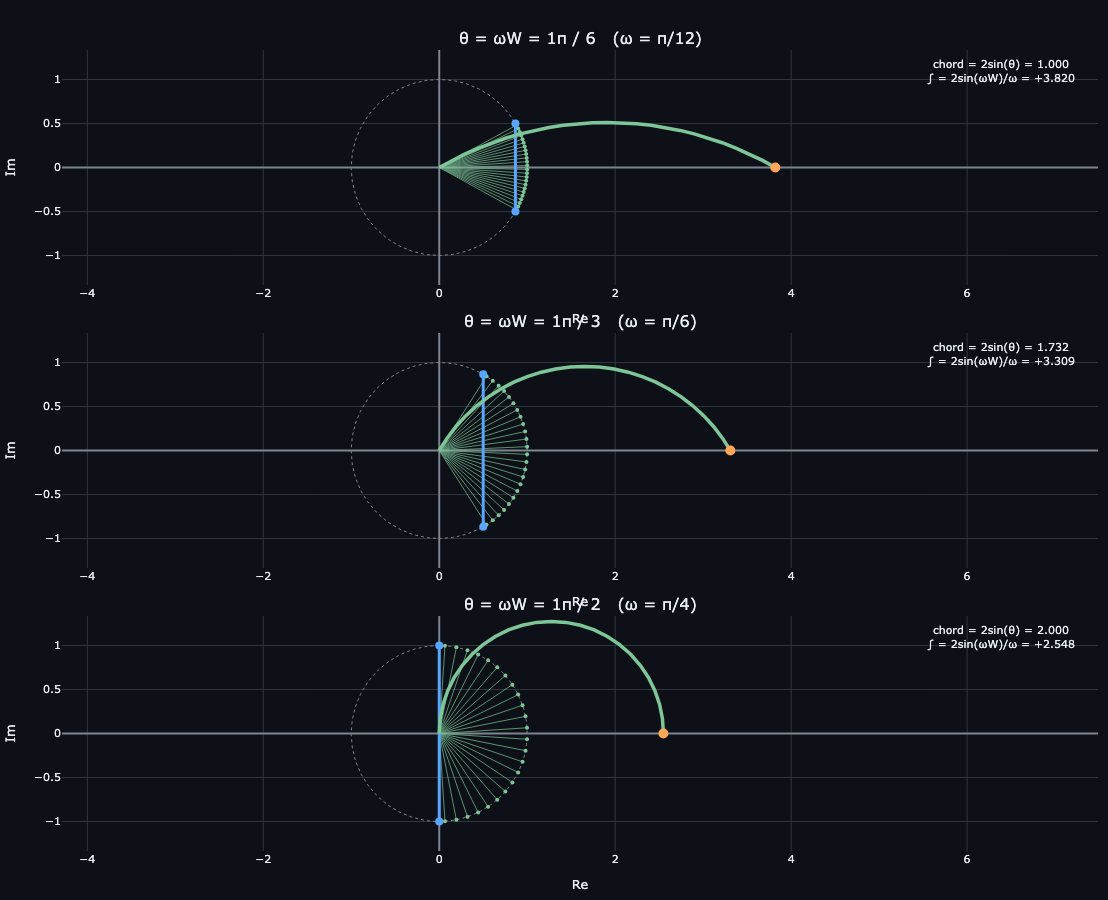


θ        ω        chord = 2sin(θ)   ∫ = 2sin(ωW)/ω
  0.167π   0.2618   1.0000            3.8197
  0.333π   0.5236   1.7321            3.3080
  0.500π   0.7854   2.0000            2.5465


In [29]:
thetas_phase1 = [np.pi/6, np.pi/3, np.pi/2]
N_ARROWS_P1 = 24   # 단위벡터 화살표 개수 — 호 위 점들이 시각적으로 알아볼 만하게

# 가로 범위: 모든 누적 호 끝점이 들어오게. θ=π/6에서 끝점 = 2sin(π/6)/(π/12) ≈ 3.82
X_MAX = 4.5
X_MIN = -1.3
Y_LIM = 1.3

fig = go.Figure()
fig.set_subplots(rows=3, cols=1, vertical_spacing=0.06,
                 subplot_titles=[f'θ = ωW = {n}π / {d}   (ω = π/{12 if d==6 else 6 if d==3 else 4})'
                                 for n, d in [(1,6),(1,3),(1,2)]])

for row, theta in enumerate(thetas_phase1, start=1):
    omega = theta / W

    # 단위벡터 t_k들 (균등 시간 분할, midpoint rule)
    dt = 2 * W / N_ARROWS_P1
    t_k = -W + np.arange(N_ARROWS_P1) * dt + dt / 2
    unit_vecs = np.exp(-1j * omega * t_k)        # 단위원 위 N개 점
    arrows = unit_vecs * dt                       # midpoint 적분 항
    cum = np.concatenate([[0+0j], np.cumsum(arrows)])

    # 단위원 (점선)
    th = np.linspace(0, 2*np.pi, 200)
    fig.add_trace(go.Scatter(x=np.cos(th), y=np.sin(th), mode='lines',
                             line=dict(color=_AXIS, width=1, dash='dot'),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)

    # 단위벡터 화살표 N개 (얇은 선) — None separator로 한 trace에
    n = len(unit_vecs)
    xs = np.empty(3*n); ys = np.empty(3*n)
    xs[0::3] = 0;  xs[1::3] = unit_vecs.real;  xs[2::3] = np.nan
    ys[0::3] = 0;  ys[1::3] = unit_vecs.imag;  ys[2::3] = np.nan
    fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines',
                             line=dict(color=_GREEN, width=1),
                             opacity=0.7, hoverinfo='skip', showlegend=False),
                  row=row, col=1)
    # 단위벡터 끝점 마커
    fig.add_trace(go.Scatter(x=unit_vecs.real, y=unit_vecs.imag,
                             mode='markers',
                             marker=dict(color=_GREEN, size=4),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)

    # chord (호 양 끝점을 잇는 직선)
    p_start = np.exp(-1j * omega * (-W))    # = e^(+jωW)
    p_end = np.exp(-1j * omega * W)         # = e^(-jωW)
    fig.add_trace(go.Scatter(x=[p_start.real, p_end.real],
                             y=[p_start.imag, p_end.imag],
                             mode='lines+markers',
                             line=dict(color=_BLUE, width=3),
                             marker=dict(color=_BLUE, size=8),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)

    # 누적 호 (원점 → ··· → (2sin(θ)/ω, 0))
    fig.add_trace(go.Scatter(x=cum.real, y=cum.imag,
                             mode='lines',
                             line=dict(color=_GREEN, width=3.5),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)
    # 누적 끝점 마커 = X(jω)
    fig.add_trace(go.Scatter(x=[cum.real[-1]], y=[cum.imag[-1]],
                             mode='markers',
                             marker=dict(color=_ORANGE, size=10, symbol='circle'),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)

    # 라벨
    chord_len = abs(p_end - p_start)
    integ = cum[-1]
    fig.add_annotation(
        text=(f'chord = 2sin(θ) = {chord_len:.3f}<br>'
              f'∫ = 2sin(ωW)/ω = {integ.real:+.3f}'),
        xref=f'x{row} domain' if row>1 else 'x domain',
        yref=f'y{row} domain' if row>1 else 'y domain',
        x=0.98, y=0.98, xanchor='right', yanchor='top',
        showarrow=False, font=dict(color=_FG, size=11),
    )

fig.update_layout(
    paper_bgcolor=_BG, plot_bgcolor=_BG,
    font=dict(color=_FG, size=11),
    margin=dict(l=10, r=10, t=50, b=20),
    height=900, showlegend=False,
)
ax_pairs = [('xaxis', 'y'), ('xaxis2', 'y2'), ('xaxis3', 'y3')]
for ax_name, scale_target in ax_pairs:
    fig.layout[ax_name].update(range=[X_MIN, X_MAX], gridcolor=_GRID,
                                zerolinecolor=_AXIS, color=_FG,
                                scaleanchor=scale_target, scaleratio=1,
                                title='Re')
for ay in ['yaxis', 'yaxis2', 'yaxis3']:
    fig.layout[ay].update(range=[-Y_LIM, Y_LIM], gridcolor=_GRID,
                          zerolinecolor=_AXIS, color=_FG, title='Im')
fig.show()

# 수치 확인
print('\nθ        ω        chord = 2sin(θ)   ∫ = 2sin(ωW)/ω')
for theta in thetas_phase1:
    omega = theta / W
    chord = 2 * np.sin(theta)
    integ_th = 2 * np.sin(omega * W) / omega
    print(f'  {theta/np.pi:.3f}π   {omega:.4f}   {chord:.4f}            {integ_th:.4f}')

**메시지**: chord 길이 = 2·sin(θ) — sin이 그림에서 직접 보인다. θ가 π/6, π/3, π/2로 변하면 sin은 0.5, 0.866, 1로 변한다. 적분값(주황 끝점)은 chord 방향으로 정확히 같은 비율 변화 + 호 길이 / ω 만큼 추가 스케일링 (Phase 2에서 다룸).

## Phase 2 — `1/ω` 감쇠가 어디서 나오는가

이제 잔여각 $\theta_\text{res} = \pi/6$을 **고정**하고 ω를 점점 키운다. 그러면 ω가 클수록 적분 구간 [-W, W] 안에 단위벡터의 한 주기(2π)가 더 많이 들어간다 — 그 주기 묶음들은 정확히 cancel되어 0. 남는 건 *마지막 못 채운 잔여 호*뿐.

조건: $2\omega W = 2\pi n + \pi/6$ → ω_n = (12n + 1)π/24 (W=2).

| n | 사라지는 주기 묶음 | ω_n | 총 회전각 |
|---|---|---|---|
| 0 | 0 (잔여만) | π/24 | π/6 |
| 1 | 1 주기 | 13π/24 | 2π + π/6 |
| 2 | 2 주기 | 25π/24 | 4π + π/6 |
| 3 | 3 주기 | 37π/24 | 6π + π/6 |

**핵심 관찰**: 잔여 호의 chord 길이는 모두 동일 (2sin(π/12) ≈ 0.518). 그런데 *적분값*은 1/ω로 줄어든다. 이유는 같은 호를 만드는 데 들인 시간이 ω에 반비례하게 줄었기 때문 — 각 단위벡터의 가중치 dt는 같지만, ω가 클수록 단위벡터들이 단위원 위에서 *듬성하게* 분포 (밀도 ∝ 1/ω). 그래서 적분 = chord × (1/ω 비례 가중치).

각 패널은 Phase 1과 같은 한 복소평면 — 왼쪽에 단위원과 단위벡터들 (회색 = 한 주기 묶음, 초록 = 잔여 호), 거기서 시작해 Re축으로 뻗는 누적 호. ω가 커질수록:
- 회색 묶음(한 주기 cancel)이 1, 2, 3개로 늘어남
- 회색 + 잔여 단위벡터들의 *간격*이 ω·Δt로 듬성해짐
- 누적 호 끝점이 1/ω로 Re축의 작은 값으로 수렴

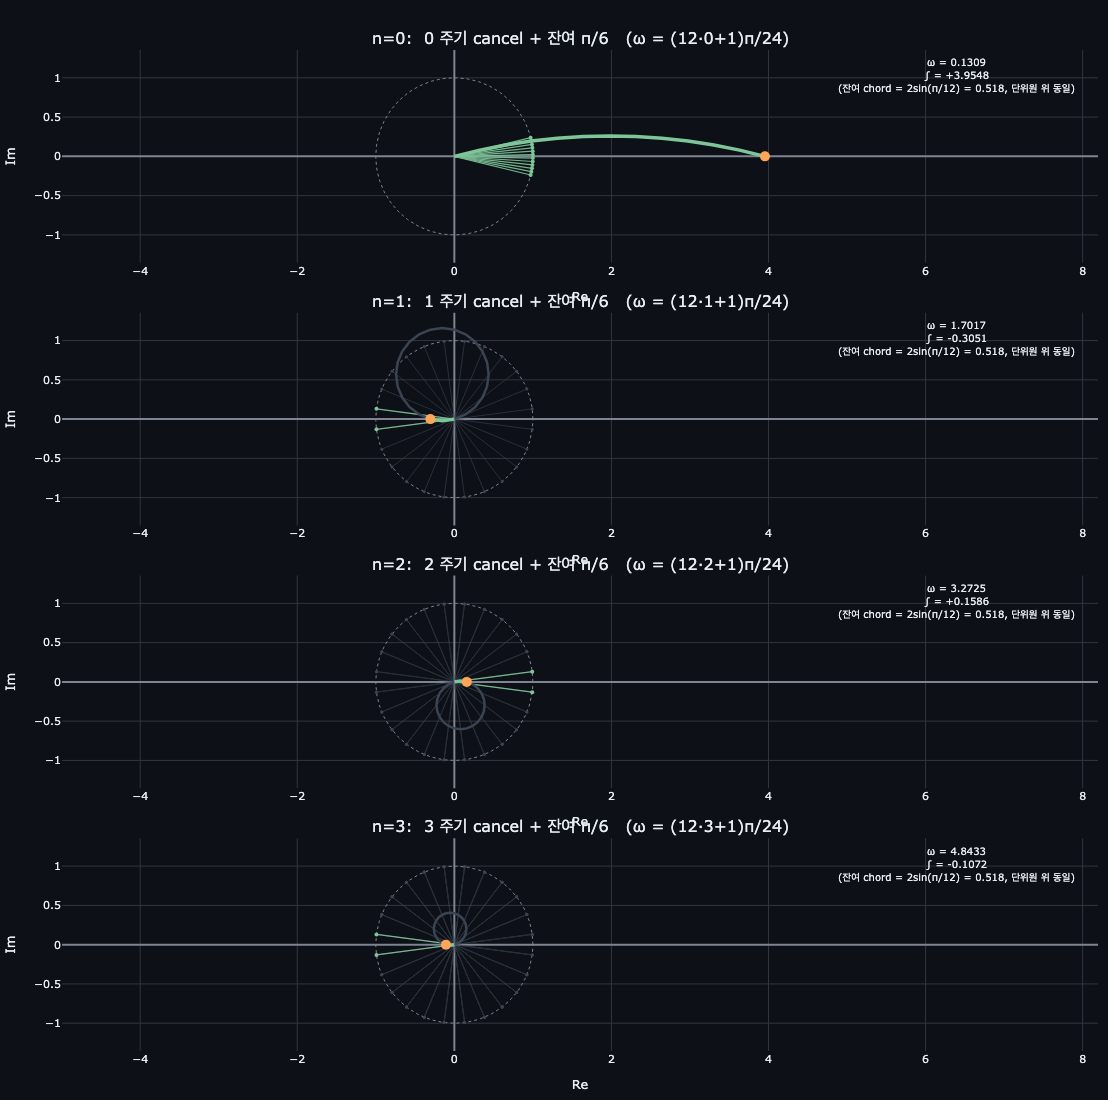


n   ω         |∫|     ∫.real      ∫.imag       chord_len_unit_circle
0   0.1309   3.9545   +3.9545   +0.0000   0.5176
1   1.7017   0.3042   -0.3042   -0.0000   0.5176
2   3.2725   0.1582   +0.1582   +0.0000   0.5176
3   4.8433   0.1069   -0.1069   +0.0000   0.5176


In [30]:
ns_phase2 = [0, 1, 2, 3]

# Phase 1과 같은 가로 범위 — 1/ω 감쇠가 끝점 위치에서 직접 보이도록
X_MAX_P2 = 4.5
X_MIN_P2 = -1.3
Y_LIM_P2 = 1.3

# 각 ω_n에서 단위벡터 화살표 개수: 한 주기당 12개 정도면 시각적으로 OK.
# n=0은 잔여만 있으니 12개; n=k는 (k 주기 + 잔여) 가 12·(k+0.5) ≈ 12k+6개 정도가 적당.
# (잔여각 π/6은 한 주기 2π의 1/12라 6개가 아니라 2개 — 너무 작음 → 한 주기에 24개로 잡고
#  잔여 6개로 가는 게 잔여 시각화에 더 좋음)
ARROWS_PER_PERIOD = 24

fig = go.Figure()
fig.set_subplots(rows=4, cols=1, vertical_spacing=0.05,
                 subplot_titles=[f'n={n}:  {n} 주기 cancel + 잔여 π/6   '
                                 f'(ω = (12·{n}+1)π/24)' for n in ns_phase2])

for row, n in enumerate(ns_phase2, start=1):
    omega = (12 * n + 1) * np.pi / 24      # W=2 가정
    # 단위벡터 개수: 한 주기당 ARROWS_PER_PERIOD개 + 잔여(잔여각 π/6 = 한 주기의 1/12)
    n_per = ARROWS_PER_PERIOD * n          # n주기 묶음
    n_res = ARROWS_PER_PERIOD // 12         # 잔여 (대략, 한 주기/12)
    n_total = max(n_per + n_res, 12)        # n=0이면 12개 (잔여만이지만 시각화 위해 충분히)

    dt = 2 * W / n_total
    t_k = -W + np.arange(n_total) * dt + dt / 2
    unit_vecs = np.exp(-1j * omega * t_k)
    arrows = unit_vecs * dt
    cum = np.concatenate([[0+0j], np.cumsum(arrows)])

    # 한 주기 묶음 / 잔여 분기 — 정확한 boundary는 t축에서 (-W + n주기길이)
    # 한 주기 시간 = 2π/ω. n주기 = n·2π/ω. boundary t = -W + n·2π/ω
    # 거기까지의 단위벡터 개수 = n·2π / (ω·dt)
    one_period_arrows = 2 * np.pi / (omega * dt)   # float
    boundary = int(round(n * one_period_arrows))   # 정수 인덱스

    # 단위원 (점선)
    th = np.linspace(0, 2*np.pi, 200)
    fig.add_trace(go.Scatter(x=np.cos(th), y=np.sin(th), mode='lines',
                             line=dict(color=_AXIS, width=1, dash='dot'),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)

    # 한 주기 묶음 단위벡터 화살표 (회색 dim) — 0..boundary-1
    if boundary > 0:
        uv_dim = unit_vecs[:boundary]
        m = len(uv_dim)
        xs = np.empty(3*m); ys = np.empty(3*m)
        xs[0::3] = 0; xs[1::3] = uv_dim.real; xs[2::3] = np.nan
        ys[0::3] = 0; ys[1::3] = uv_dim.imag; ys[2::3] = np.nan
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines',
                                 line=dict(color=_DIM, width=1),
                                 opacity=0.6, hoverinfo='skip', showlegend=False),
                      row=row, col=1)
        fig.add_trace(go.Scatter(x=uv_dim.real, y=uv_dim.imag, mode='markers',
                                 marker=dict(color=_DIM, size=3),
                                 hoverinfo='skip', showlegend=False),
                      row=row, col=1)

    # 잔여 단위벡터 화살표 (강조 초록) — boundary..end
    uv_res = unit_vecs[boundary:]
    m = len(uv_res)
    if m > 0:
        xs = np.empty(3*m); ys = np.empty(3*m)
        xs[0::3] = 0; xs[1::3] = uv_res.real; xs[2::3] = np.nan
        ys[0::3] = 0; ys[1::3] = uv_res.imag; ys[2::3] = np.nan
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines',
                                 line=dict(color=_GREEN, width=1.2),
                                 opacity=0.9, hoverinfo='skip', showlegend=False),
                      row=row, col=1)
        fig.add_trace(go.Scatter(x=uv_res.real, y=uv_res.imag, mode='markers',
                                 marker=dict(color=_GREEN, size=4),
                                 hoverinfo='skip', showlegend=False),
                      row=row, col=1)

    # 한 주기 묶음 누적 호 (회색)
    if boundary > 0:
        fig.add_trace(go.Scatter(x=cum.real[:boundary+1], y=cum.imag[:boundary+1],
                                 mode='lines',
                                 line=dict(color=_DIM, width=2.5),
                                 hoverinfo='skip', showlegend=False),
                      row=row, col=1)

    # 잔여 누적 호 (초록 강조) — Re축 끝점에서 멈춤
    fig.add_trace(go.Scatter(x=cum.real[boundary:], y=cum.imag[boundary:],
                             mode='lines',
                             line=dict(color=_GREEN, width=3.5),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)

    # 누적 끝점 = X(jω)
    fig.add_trace(go.Scatter(x=[cum.real[-1]], y=[cum.imag[-1]],
                             mode='markers',
                             marker=dict(color=_ORANGE, size=10, symbol='circle'),
                             hoverinfo='skip', showlegend=False),
                  row=row, col=1)

    # 라벨
    integ = cum[-1]
    fig.add_annotation(
        text=(f'ω = {omega:.4f}<br>'
              f'∫ = {integ.real:+.4f}<br>'
              f'(잔여 chord = 2sin(π/12) = 0.518, 단위원 위 동일)'),
        xref=f'x{row} domain' if row>1 else 'x domain',
        yref=f'y{row} domain' if row>1 else 'y domain',
        x=0.98, y=0.98, xanchor='right', yanchor='top',
        showarrow=False, font=dict(color=_FG, size=10),
    )

fig.update_layout(
    paper_bgcolor=_BG, plot_bgcolor=_BG,
    font=dict(color=_FG, size=11),
    margin=dict(l=10, r=10, t=50, b=20),
    height=1100, showlegend=False,
)
ax_pairs_p2 = [('xaxis', 'y'), ('xaxis2', 'y2'),
                ('xaxis3', 'y3'), ('xaxis4', 'y4')]
for ax_name, scale_target in ax_pairs_p2:
    fig.layout[ax_name].update(range=[X_MIN_P2, X_MAX_P2], gridcolor=_GRID,
                                zerolinecolor=_AXIS, color=_FG,
                                scaleanchor=scale_target, scaleratio=1,
                                title='Re')
for ay in ['yaxis', 'yaxis2', 'yaxis3', 'yaxis4']:
    fig.layout[ay].update(range=[-Y_LIM_P2, Y_LIM_P2], gridcolor=_GRID,
                          zerolinecolor=_AXIS, color=_FG, title='Im')
fig.show()

# 수치 확인 표 (정확한 적분은 dense 샘플링으로)
print('\nn   ω         |∫|     ∫.real      ∫.imag       chord_len_unit_circle')
for n in ns_phase2:
    omega = (12*n + 1) * np.pi / 24
    arrows_d, cum_d, chord_pts_d = make_unit_arrows(omega, W, n_points=2000)
    integ = cum_d[-1]
    chord_unit = abs(chord_pts_d[1] - chord_pts_d[0])
    print(f'{n}   {omega:.4f}   {abs(integ):.4f}   {integ.real:+.4f}   {integ.imag:+.4f}   {chord_unit:.4f}')

**메시지**: 단위원 위에서 보면 호의 모양은 모두 같다 (chord ≈ 0.518, 잔여각 π/6). 그런데 적분값(주황 끝점)은 1/ω로 줄어든다. 동일한 호를 만든 *시간*이 ω에 반비례해 줄었기 때문. 회색은 사라지는 주기 묶음 — 묶음이 1, 2, 3개로 늘어남.

수치 표에서:
- 모든 n에서 단위원 chord 길이 = 0.5176 (= 2sin(π/12))로 동일.
- |∫|는 n이 커질수록 ω가 커지고 1/ω로 감소 — 정확히 chord/ω 패턴.

## Phase 3 — 두 항을 합치면 sinc

지금까지:
- chord = 2sin(ωW) — Phase 1
- 적분값의 크기 = chord / ω = 2sin(ωW)/ω — Phase 2

이게 정확히 X(jω). ftvis.SpectrumPlot으로 ω 전 범위에서 직접 그려 모양을 확인.

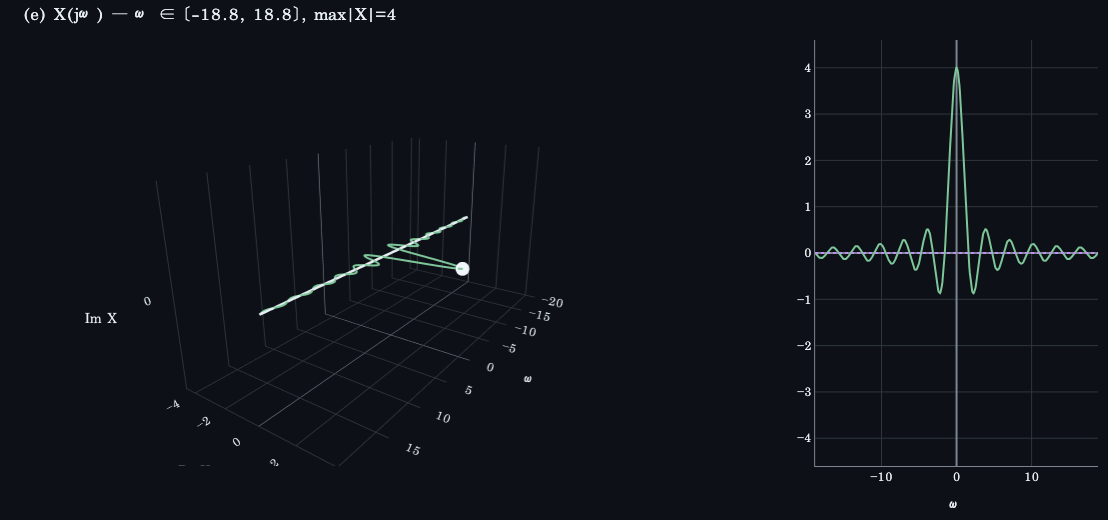

max|X_numerical - 2sin(ωW)/ω| = 3.39e-06
X(0) = 4.0000  (expect 2W = 4.0)
first zero at ω = π/W = 1.5708, X(π/W) ≈ -0.0000+0.0000j


In [31]:
sig = signals.rect(width=2*W)   # signals.rect의 width는 *전체 폭*. 반폭 W=2 → width=4
analyzer = FourierAnalyzer(sig, t_min=-W-1, t_max=W+1, n_samples=4000)

omegas, X = analyzer.spectrum(omega_min=-6*np.pi, omega_max=6*np.pi, n_omega=601)

panel = SpectrumPlot(view='re_im', show_inset=True)
panel.show_spectrum(omegas, X)
panel.figure.show()

# 분석적 비교
X_analytic = 2 * np.sin(omegas * W) / np.where(np.abs(omegas) < 1e-9, 1.0, omegas)
X_analytic = np.where(np.abs(omegas) < 1e-9, 2*W, X_analytic)
err = float(np.max(np.abs(X - X_analytic)))
print(f'max|X_numerical - 2sin(ωW)/ω| = {err:.2e}')
print(f'X(0) = {X[np.argmin(np.abs(omegas))].real:.4f}  (expect 2W = {2*W})')
print(f'first zero at ω = π/W = {np.pi/W:.4f}, X(π/W) ≈ {complex(X[np.argmin(np.abs(omegas - np.pi/W))]):.4f}')

**관찰**:
- X(jω)는 **순수 실수** (rect가 짝함수라서 — 02_inverse Part D2와 같은 패턴).
- X(0) = 2W = 4 (DC 값 = 신호의 시간 적분).
- 첫 영점 ω = π/W = π/2 — Phase 2의 잔여각이 0이 되는 (= 호가 정확히 한 바퀴를 닫는) 지점.
- 이후 영점들도 ω = nπ/W에서 — 정확히 호가 n바퀴를 닫는 지점.

3D trail이 ω축을 따라 휘감기지 않고 ω축 평면(Im X = 0) 위에 정확히 누워 있는 것을 확인할 수 있다.

## Phase 4 — 역변환: sinc → rect 복원

지금까지 *순방향* 변환 X(jω) = ∫_{-W}^{W} e^{-jωt} dt를 기하적으로 분해했다. 이제 *역방향* — sinc를 다시 rect로 되돌려본다.

역변환:
$$
x(t_\text{fix}) = \frac{1}{2\pi}\int X(j\omega)\, e^{j\omega t_\text{fix}}\, d\omega
$$

이걸 ω별 화살표 `(1/2π)·X(jω)·e^{jωt_fix}·dω`의 머리잇기 누적으로 본다 ([02_inverse.ipynb](./02_inverse.ipynb) 참조). 누적 끝점이 곧 `x(t_fix)` = rect_W(t_fix).

**기대 결과**:
- 펄스 외부 (`|t_fix| > W`): 끝점이 0 부근.
- 펄스 경계 (`|t_fix| = W`): 끝점이 0.5 (사다리꼴 적분의 자연스러운 결과).
- 펄스 내부 (`|t_fix| < W`): 끝점이 1 부근.

펄스 내부/경계/외부 4개 t_fix에서 누적 trail의 *모양*이 어떻게 다른지 small multiples로 비교한다.

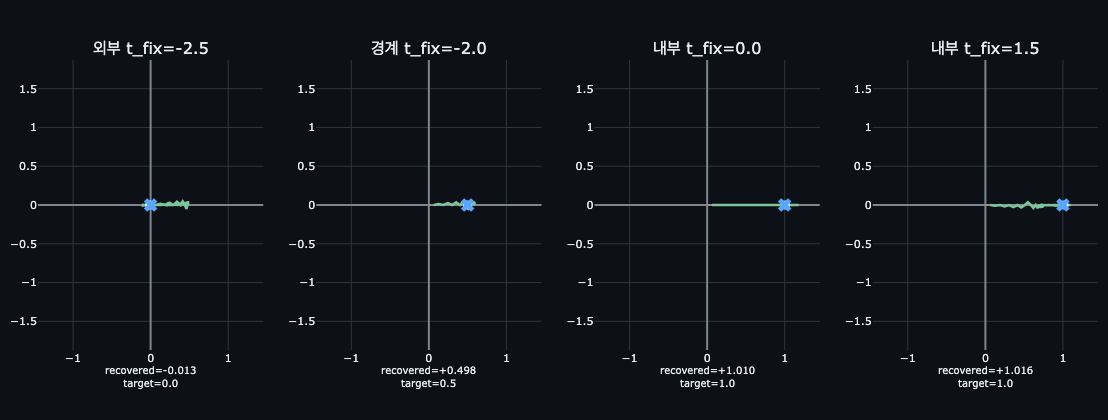


  t_fix     rect_W(t_fix)   recovered            |error|
  ──────────────────────────────────────────────────────
  -3.00     0.000           (-0.0000,+0.0000)    1.31e-05
  -2.50     0.000           (-0.0131,-0.0000)    1.31e-02
  -2.00     0.500           (+0.4982,-0.0000)    1.84e-03
  -1.00     1.000           (+1.0002,-0.0000)    2.03e-04
  +0.00     1.000           (+1.0098,+0.0000)    9.80e-03
  +1.00     1.000           (+1.0002,+0.0000)    2.03e-04
  +1.50     1.000           (+1.0157,-0.0000)    1.57e-02
  +2.00     0.500           (+0.4982,+0.0000)    1.84e-03
  +2.50     0.000           (-0.0131,+0.0000)    1.31e-02
  +3.00     0.000           (-0.0000,-0.0000)    1.31e-05


In [32]:
# Phase 3에서 만든 spectrum 데이터를 더 넓은 ω 범위로 다시 (역변환 정확도 확보)
omegas_inv, X_inv = analyzer.spectrum(omega_min=-30, omega_max=30, n_omega=601)
domega_inv = float(omegas_inv[1] - omegas_inv[0])

t_fix_panels = [-2.5, -2.0, 0.0, 1.5]   # 외부 / 경계 / 내부 / 내부
labels = ['외부 t_fix=-2.5', '경계 t_fix=-2.0', '내부 t_fix=0.0', '내부 t_fix=1.5']

# paired_by_abs 순서로 정렬 (켤레 cancel이 깨끗)
order_idx = np.argsort(np.abs(omegas_inv))
om_o = omegas_inv[order_idx]
X_o = X_inv[order_idx]

fig = go.Figure()
fig.set_subplots(rows=1, cols=4, horizontal_spacing=0.05,
                 subplot_titles=labels)

# 모든 패널 동일한 축 범위 — 각 t_fix에서 누적 끝점/trail의 *상대적 크기*가 직접 비교됨
all_re_ranges = []
all_im_ranges = []
accums = []
for t_fix in t_fix_panels:
    arrows = X_o * np.exp(1j * om_o * t_fix) * domega_inv / (2 * np.pi)
    accum = np.cumsum(arrows)
    accums.append((arrows, accum, t_fix))
    all_re_ranges.append((accum.real.min(), accum.real.max()))
    all_im_ranges.append((accum.imag.min(), accum.imag.max()))

# 모든 trail이 들어오는 정사각 범위
re_max = max(max(abs(lo), abs(hi)) for lo, hi in all_re_ranges)
im_max = max(max(abs(lo), abs(hi)) for lo, hi in all_im_ranges)
lim_p4 = max(re_max, im_max, 1.0) * 1.2

for col, (arrows, accum, t_fix) in enumerate(accums, start=1):
    # 화살표 줄기 (None separator)
    starts = accum - arrows
    ends = accum
    n = len(arrows)
    xs = np.empty(3*n); ys = np.empty(3*n)
    xs[0::3] = starts.real; xs[1::3] = ends.real; xs[2::3] = np.nan
    ys[0::3] = starts.imag; ys[1::3] = ends.imag; ys[2::3] = np.nan
    fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines',
                             line=dict(color=_ORANGE, width=1.2),
                             opacity=0.45, hoverinfo='skip', showlegend=False),
                  row=1, col=col)
    # 누적 trail
    fig.add_trace(go.Scatter(x=accum.real, y=accum.imag, mode='lines',
                             line=dict(color=_GREEN, width=2.5),
                             hoverinfo='skip', showlegend=False),
                  row=1, col=col)
    # 끝점
    fig.add_trace(go.Scatter(x=[accum.real[-1]], y=[accum.imag[-1]],
                             mode='markers',
                             marker=dict(color='#f0f6fc', size=9),
                             hoverinfo='skip', showlegend=False),
                  row=1, col=col)
    # 분석값 target (X 마커)
    arg = t_fix
    if abs(abs(arg) - W) < 1e-9:
        analytic = 0.5
    elif abs(arg) < W:
        analytic = 1.0
    else:
        analytic = 0.0
    fig.add_trace(go.Scatter(x=[analytic], y=[0.0],
                             mode='markers',
                             marker=dict(color=_BLUE, size=12, symbol='x'),
                             hoverinfo='skip', showlegend=False),
                  row=1, col=col)
    fig.add_annotation(
        text=f'recovered={accum[-1].real:+.3f}<br>target={analytic:.1f}',
        xref=f'x{col} domain' if col>1 else 'x domain',
        yref=f'y{col} domain' if col>1 else 'y domain',
        x=0.5, y=-0.04, xanchor='center', yanchor='top',
        showarrow=False, font=dict(color=_FG, size=10),
    )

fig.update_layout(
    paper_bgcolor=_BG, plot_bgcolor=_BG,
    font=dict(color=_FG, size=11),
    margin=dict(l=10, r=10, t=60, b=70),
    height=420, showlegend=False,
)
ax_pairs_p4 = [('xaxis', 'y'), ('xaxis2', 'y2'), ('xaxis3', 'y3'), ('xaxis4', 'y4')]
for ax_name, scale_target in ax_pairs_p4:
    fig.layout[ax_name].update(range=[-lim_p4, lim_p4],
                                gridcolor=_GRID, zerolinecolor=_AXIS, color=_FG,
                                scaleanchor=scale_target, scaleratio=1)
for ay in ['yaxis', 'yaxis2', 'yaxis3', 'yaxis4']:
    fig.layout[ay].update(range=[-lim_p4, lim_p4],
                          gridcolor=_GRID, zerolinecolor=_AXIS, color=_FG)
fig.show()

# 정확도 표
print('\n  t_fix     rect_W(t_fix)   recovered            |error|')
print('  ──────────────────────────────────────────────────────')
for t_fix in [-3.0, -2.5, -2.0, -1.0, 0.0, 1.0, 1.5, 2.0, 2.5, 3.0]:
    arrows = X_o * np.exp(1j * om_o * t_fix) * domega_inv / (2 * np.pi)
    rec = complex(np.sum(arrows))
    if abs(abs(t_fix) - W) < 1e-9:
        a = 0.5
    elif abs(t_fix) < W:
        a = 1.0
    else:
        a = 0.0
    err = abs(rec.real - a)
    print(f'  {t_fix:+5.2f}     {a:.3f}           ({rec.real:+.4f},{rec.imag:+.4f})    {err:.2e}')

**관찰**:
- 외부 `t_fix=-2.5`: trail이 작은 영역을 맴돌다 끝점도 0 근처. 모든 ω 성분이 cancel.
- 경계 `t_fix=-2`: 끝점 ≈ 0.5. 사다리꼴 적분의 자연스러운 결과 — Gibbs phenomenon의 일종.
- 내부 `t_fix=0`: 끝점 ≈ 1. trail이 크게 휘돌면서 누적되는 모양.
- 내부 `t_fix=1.5`: 끝점도 ≈ 1. `t_fix=0`과는 trail의 *모양*이 다름 (linear phase 효과의 전조 — Phase 5에서 다룸).

수치 표에서 모든 허수부가 ≈ 0 (실수 신호의 켤레쌍 cancel — paired_by_abs 정렬). 펄스 외부 오차는 sinc tail의 truncation 영향.

## Phase 5 — Linear phase = time shift

푸리에 변환의 *time shift property*:
$$
x(t - \alpha) \;\longleftrightarrow\; X(j\omega)\cdot e^{-j\omega\alpha}
$$

수식 차원에서는 자명하지만, 역변환 누적 시각화로 보면 *왜 그런지*가 그림에서 직접 보인다.

역변환 적분 안에 X 대신 `X(jω)·e^(-jωα)`를 넣으면 `e^(-jωα)·e^(jωt) = e^(jω(t-α))`. 즉 `t_fix`를 **t* + α**로 잡으면 정확히 원본 X에서 `t_fix = t*`로 잡은 적분과 *같은 화살표 시퀀스*가 만들어진다.

데모: α = 1.5. rect_W(t)를 오른쪽으로 1.5만큼 평행이동한 신호 = rect_W(t-1.5)는 |t-1.5|<2 즉 `-0.5 < t < 3.5`에서 1.

### 5.1 — 3D 시각화로 Linear phase의 정체를 본다

먼저 `X(jω)·e^(-jωα)`가 *어떻게 생겼는지* 3D로 본다.

**(a) 원본 sinc `X(jω)`** — 짝함수라 순수 실수, ω축을 따라가는 *평면* 위 곡선 (Im X = 0, flatten_noise 작동).

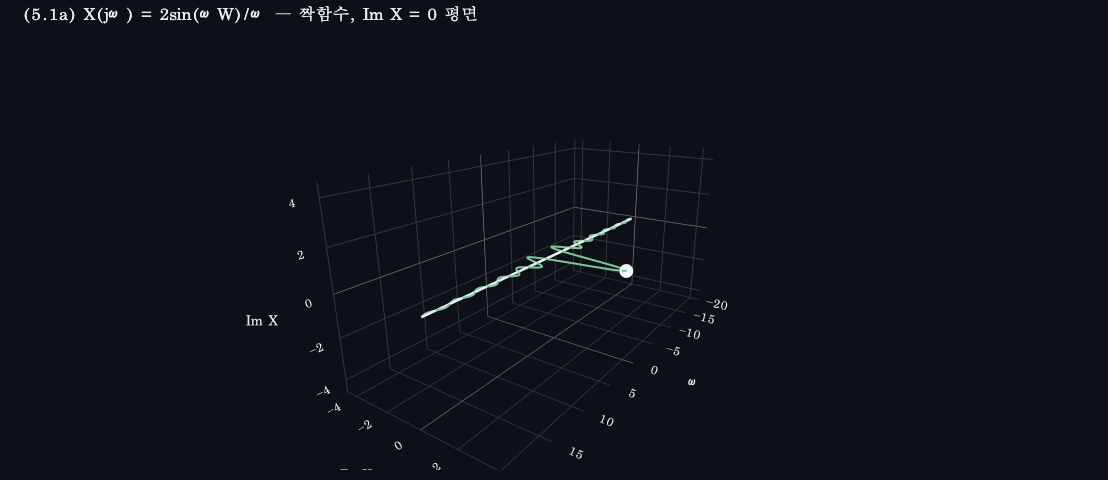

In [33]:
ALPHA = 1.5  # 평행이동량
omegas_3d = np.linspace(-6*np.pi, 6*np.pi, 401)
X_3d_orig = 2 * np.sin(omegas_3d * W) / np.where(np.abs(omegas_3d) < 1e-9, 1.0, omegas_3d)
X_3d_orig = np.where(np.abs(omegas_3d) < 1e-9, 2*W, X_3d_orig).astype(complex)

panel_orig = SpectrumPlot(view='re_im', show_inset=False)
panel_orig.show_spectrum(omegas_3d, X_3d_orig)
panel_orig.figure.layout.title.text = '(5.1a) X(jω) = 2sin(ωW)/ω — 짝함수, Im X = 0 평면'
panel_orig.figure.show()

**(b) Linear phase `e^(-jωα)`** — 단위 헬릭스. ω 따라 `(cos(ωα), -sin(ωα))`로 일정한 각속도 -α로 회전. envelope = 1 (단위원통)

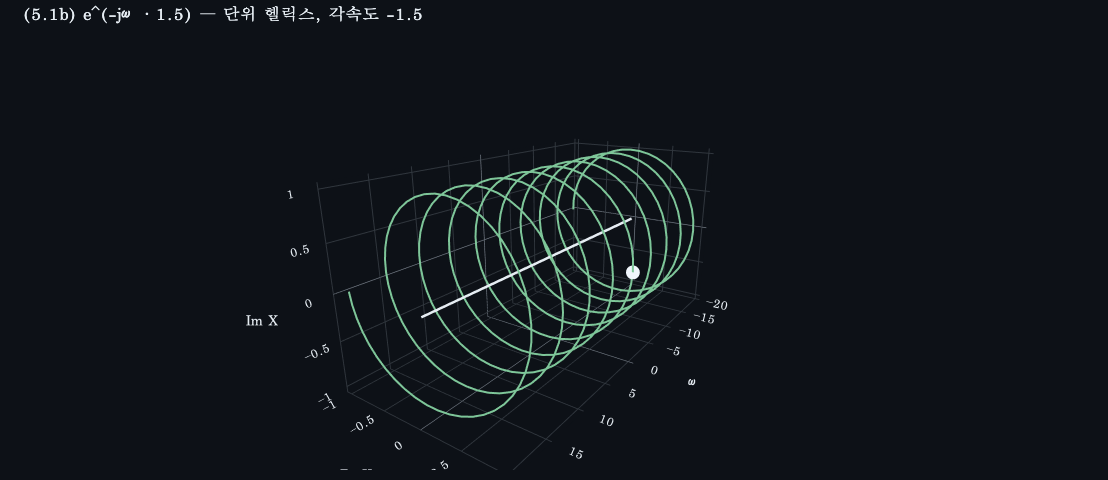

In [34]:
# 단위 헬릭스를 SpectrumPlot 좌표계 (ω, Re, Im)에 띄움
unit_phase = np.exp(-1j * omegas_3d * ALPHA)
panel_phase = SpectrumPlot(view='re_im', show_inset=False)
panel_phase.show_spectrum(omegas_3d, unit_phase)
panel_phase.figure.layout.title.text = (
    f'(5.1b) e^(-jω·{ALPHA}) — 단위 헬릭스, 각속도 -{ALPHA}'
)
panel_phase.figure.show()

**(c) `X(jω)·e^(-jωα)`** — 핵심 그림. carrier는 (b)의 헬릭스 모양 그대로지만 *반지름이 sinc로 변조*된다. envelope `|sinc|`를 ω축에 회전시킨 회전체로 함께 그려 헬릭스가 그 안에 정확히 들어차는 모습이 보임. envelope의 zero crossing(ω = nπ/W)에서 회전체가 ω축에 닿음.

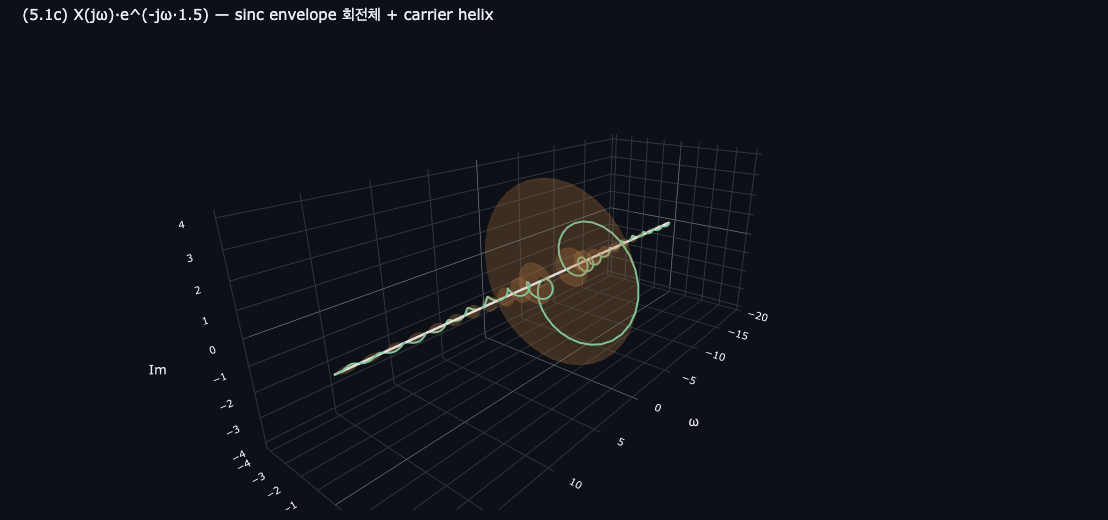

envelope max = 4.000  (= 2W = 4.0)
envelope zeros at ω = ±π/W, ±2π/W, ... = ±1.571, ±3.142, ...


In [35]:
# carrier: X(jω)·e^(-jωα)
X_3d_shift = X_3d_orig * np.exp(-1j * omegas_3d * ALPHA)

# raw plotly로 직접 그림 — envelope 회전체 surface + helix curve + 중심축
fig = go.Figure()

# 중심축 (ω, 0, 0)
fig.add_trace(go.Scatter3d(
    x=[float(omegas_3d[0]), float(omegas_3d[-1])],
    y=[0, 0], z=[0, 0],
    mode='lines',
    line=dict(color=_FG, width=5),
    opacity=1.0, hoverinfo='skip', showlegend=False,
))

# Envelope 회전체 — 반지름 = |X(jω)|를 ω축에 대해 회전
# 다운샘플 (surface가 무거워지지 않게)
stride = max(1, len(omegas_3d) // 200)
om_ds = omegas_3d[::stride]
amp_ds = np.abs(X_3d_orig[::stride])  # |sinc|
N_THETA = 36
theta = np.linspace(0, 2*np.pi, N_THETA + 1)
T_grid, Th_grid = np.meshgrid(om_ds, theta, indexing='ij')
A_grid, _ = np.meshgrid(amp_ds, theta, indexing='ij')
fig.add_trace(go.Surface(
    x=T_grid, y=A_grid * np.cos(Th_grid), z=A_grid * np.sin(Th_grid),
    colorscale=[[0, _ORANGE], [1, _ORANGE]],
    showscale=False,
    opacity=0.15,
    hoverinfo='skip',
    lighting=dict(ambient=0.7, diffuse=0.4, specular=0.05),
))

# carrier helix (sinc로 변조된 e^(-jωα))
fig.add_trace(go.Scatter3d(
    x=omegas_3d, y=X_3d_shift.real, z=X_3d_shift.imag,
    mode='lines',
    line=dict(color=_GREEN, width=4),
    hoverinfo='skip', showlegend=False,
))

# 좌표계
fig.update_layout(
    paper_bgcolor=_BG, plot_bgcolor=_BG,
    font=dict(color=_FG, size=11),
    margin=dict(l=10, r=10, t=40, b=10),
    title=dict(
        text=f'(5.1c) X(jω)·e^(-jω·{ALPHA}) — sinc envelope 회전체 + carrier helix',
        x=0.02, xanchor='left',
    ),
    height=520,
    scene=dict(
        xaxis=dict(backgroundcolor=_BG, gridcolor=_GRID, zerolinecolor=_AXIS,
                   showbackground=True, color=_FG, title='ω'),
        yaxis=dict(backgroundcolor=_BG, gridcolor=_GRID, zerolinecolor=_AXIS,
                   showbackground=True, color=_FG, title='Re'),
        zaxis=dict(backgroundcolor=_BG, gridcolor=_GRID, zerolinecolor=_AXIS,
                   showbackground=True, color=_FG, title='Im'),
        aspectmode='manual',
        aspectratio=dict(x=2.5, y=1.0, z=1.0),
        camera=dict(eye=dict(x=2.0, y=1.6, z=1.0)),
    ),
    showlegend=False,
)
fig.show()

print(f'envelope max = {float(np.max(np.abs(X_3d_orig))):.3f}  (= 2W = {2*W})')
print(f'envelope zeros at ω = ±π/W, ±2π/W, ... = ±{np.pi/W:.3f}, ±{2*np.pi/W:.3f}, ...')

**메시지**: helix(초록)가 envelope(주황 회전체) 안에 정확히 들어차 있다. envelope이 0에 닿는 곳(ω = ±π/W ≈ ±1.57)에서 helix도 ω축으로 모이고, envelope의 부호가 바뀌는 부분에서 helix가 반대편 회전 방향으로 넘어간다 (sinc가 음수가 되니 phase가 π 점프).

### 5.2 — Partial 적분을 3D로 (Trail A/B/C 비교, 세 케이스)

이제 역변환 적분을 ω 누적으로 본다. 좌표: x = ω, (y, z) = (Re partial, Im partial). ω가 -Ω에서 +Ω까지 진행하면서 누적 trail이 3D 공간에서 어떻게 자라는지 본다.

각 t에 대해 세 trail을 *한 그림*에 함께 그려 비교:

| Trail | 적분 핵 | t | 끝점 |
|---|---|---|---|
| A (초록) | `X(jω) · e^(jωt)` | t | rect_W(t) |
| B (주황) | `X(jω)·e^(-jωα) · e^(jωt)` | t | rect_W(t-α) |
| C (흰 점선) | `X(jω)·e^(-jωα) · e^(jω(t+α))` | t+α | rect_W(t)  → A와 정확히 같은 trail |

세 t 케이스: **rect_W(t) = 1, 0.5, 0** 각각 (펄스 안 / 경계 / 외부)
- t = 0: A = rect_W(0) = 1, B = rect_W(-1.5) = 1   → 끝점 같음, trail 모양 다름
- t = 2: A = rect_W(2) = 0.5 (경계), B = rect_W(0.5) = 1 (안)  → 끝점도 다름
- t = 3: A = rect_W(3) = 0 (외부), B = rect_W(1.5) = 1 (안)  → 끝점이 정반대

A vs C는 모든 t에서 정확히 같음 (time shift property).

[(5.2a) t = 0 — 펄스 안 (A=B=1, trail 모양만 다름)]  t = 0.0
  Trail A 끝점 (X, t):                  +0.9832+0.0000j    target rect_W(t)   = 1.0
  Trail B 끝점 (X·e^(-jωα), t):         +1.0379-0.0000j    target rect_W(t-α) = 1.0
  Trail C 끝점 (X·e^(-jωα), t+α):       +0.9832+0.0000j    target rect_W(t)   = 1.0
  cum_A vs cum_C max diff = 1.39e-17



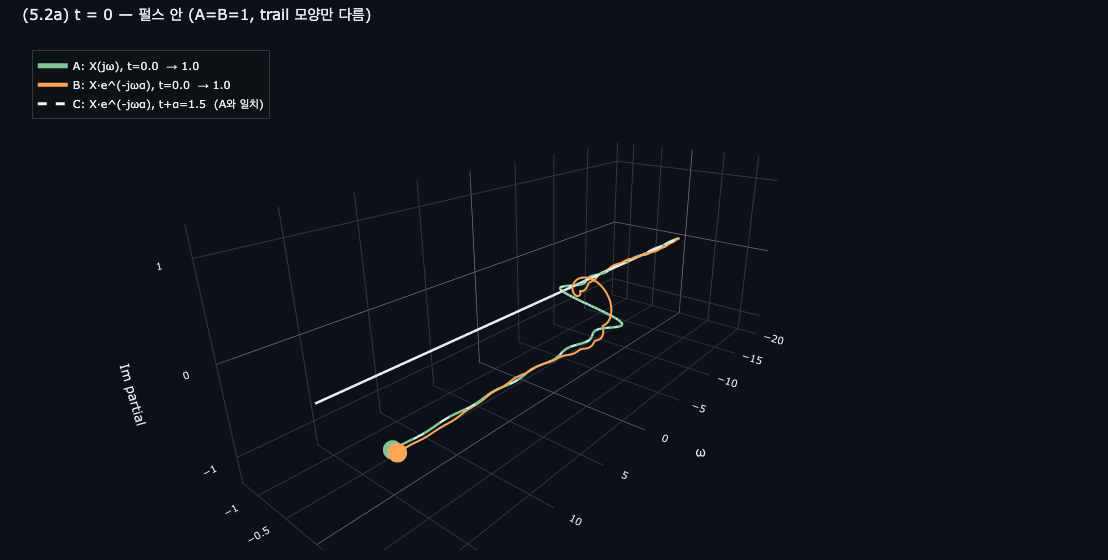

In [36]:
def partial_accum_3d(omegas, X_kernel, t):
    """X_kernel(jω)에 e^(jωt)를 곱해 ω 누적합. (1/2π) 인자 포함."""
    domega = float(omegas[1] - omegas[0])
    arrows = X_kernel * np.exp(1j * omegas * t) * domega / (2 * np.pi)
    return np.cumsum(arrows)


def rect_W(t):
    if abs(abs(t) - W) < 1e-9:
        return 0.5
    return 1.0 if abs(t) < W else 0.0


def make_three_trails_3d(t_value: float, label: str):
    """주어진 t에서 Trail A/B/C 세 개를 한 3D scene에 그린 figure 반환."""
    cum_A = partial_accum_3d(omegas_3d, X_3d_orig,  t=t_value)
    cum_B = partial_accum_3d(omegas_3d, X_3d_shift, t=t_value)
    cum_C = partial_accum_3d(omegas_3d, X_3d_shift, t=t_value + ALPHA)

    diff_AC = float(np.max(np.abs(cum_A - cum_C)))
    target_A = rect_W(t_value)
    target_B = rect_W(t_value - ALPHA)

    print(f'[{label}]  t = {t_value}')
    print(f'  Trail A 끝점 (X, t):                  {cum_A[-1]:+.4f}    target rect_W(t)   = {target_A}')
    print(f'  Trail B 끝점 (X·e^(-jωα), t):         {cum_B[-1]:+.4f}    target rect_W(t-α) = {target_B}')
    print(f'  Trail C 끝점 (X·e^(-jωα), t+α):       {cum_C[-1]:+.4f}    target rect_W(t)   = {target_A}')
    print(f'  cum_A vs cum_C max diff = {diff_AC:.2e}')
    print()

    fig = go.Figure()

    # 중심축
    fig.add_trace(go.Scatter3d(
        x=[float(omegas_3d[0]), float(omegas_3d[-1])], y=[0,0], z=[0,0],
        mode='lines', line=dict(color=_FG, width=5),
        hoverinfo='skip', showlegend=False,
    ))

    # Trail A — 굵은 초록
    fig.add_trace(go.Scatter3d(
        x=omegas_3d, y=cum_A.real, z=cum_A.imag,
        mode='lines',
        line=dict(color=_GREEN, width=5),
        name=f'A: X(jω), t={t_value}  → {target_A}',
    ))
    fig.add_trace(go.Scatter3d(
        x=[float(omegas_3d[-1])], y=[float(cum_A[-1].real)], z=[float(cum_A[-1].imag)],
        mode='markers', marker=dict(color=_GREEN, size=7),
        showlegend=False, hoverinfo='skip',
    ))

    # Trail B — 주황
    fig.add_trace(go.Scatter3d(
        x=omegas_3d, y=cum_B.real, z=cum_B.imag,
        mode='lines',
        line=dict(color=_ORANGE, width=4),
        name=f'B: X·e^(-jωα), t={t_value}  → {target_B}',
    ))
    fig.add_trace(go.Scatter3d(
        x=[float(omegas_3d[-1])], y=[float(cum_B[-1].real)], z=[float(cum_B[-1].imag)],
        mode='markers', marker=dict(color=_ORANGE, size=7),
        showlegend=False, hoverinfo='skip',
    ))

    # Trail C — 흰 점선 (A 위 덧칠)
    fig.add_trace(go.Scatter3d(
        x=omegas_3d, y=cum_C.real, z=cum_C.imag,
        mode='lines',
        line=dict(color='#f0f6fc', width=3, dash='dash'),
        name=f'C: X·e^(-jωα), t+α={t_value+ALPHA}  (A와 일치)',
    ))
    fig.add_trace(go.Scatter3d(
        x=[float(omegas_3d[-1])], y=[float(cum_C[-1].real)], z=[float(cum_C[-1].imag)],
        mode='markers', marker=dict(color='#f0f6fc', size=5, symbol='cross'),
        showlegend=False, hoverinfo='skip',
    ))

    all_re = np.concatenate([cum_A.real, cum_B.real, cum_C.real])
    all_im = np.concatenate([cum_A.imag, cum_B.imag, cum_C.imag])
    lim = float(max(np.max(np.abs(all_re)), np.max(np.abs(all_im)), 1.0)) * 1.2

    fig.update_layout(
        paper_bgcolor=_BG, plot_bgcolor=_BG,
        font=dict(color=_FG, size=11),
        margin=dict(l=10, r=10, t=40, b=10),
        title=dict(text=label, x=0.02, xanchor='left'),
        height=560,
        scene=dict(
            xaxis=dict(backgroundcolor=_BG, gridcolor=_GRID, zerolinecolor=_AXIS,
                       showbackground=True, color=_FG, title='ω'),
            yaxis=dict(backgroundcolor=_BG, gridcolor=_GRID, zerolinecolor=_AXIS,
                       showbackground=True, color=_FG, title='Re partial',
                       range=[-lim, lim]),
            zaxis=dict(backgroundcolor=_BG, gridcolor=_GRID, zerolinecolor=_AXIS,
                       showbackground=True, color=_FG, title='Im partial',
                       range=[-lim, lim]),
            aspectmode='manual',
            aspectratio=dict(x=2.5, y=1.0, z=1.0),
            camera=dict(eye=dict(x=2.0, y=1.6, z=1.0)),
        ),
        showlegend=True,
        legend=dict(x=0.02, y=0.98, bgcolor='rgba(13,17,23,0.7)',
                    bordercolor=_GRID, borderwidth=1),
    )
    return fig


# 케이스 1: t=0 — 펄스 안 (A=1, B=1, 같은 끝점, trail 모양 다름)
fig_t0 = make_three_trails_3d(t_value=0.0,
    label='(5.2a) t = 0 — 펄스 안 (A=B=1, trail 모양만 다름)')
fig_t0.show()

**(5.2a) t=0**: A와 B 모두 펄스 안이라 *끝점은 같지만 trail 모양이 다르다*. linear phase가 곱해진 B는 ω 따라 더 회전된 경로로 누적된 뒤 같은 점에 도달. C는 t→t+α=1.5 보정으로 A와 정확히 일치 (흰 점선이 초록 trail 위에 덧칠).

[(5.2b) t = 2 — A는 펄스 경계 (=0.5), B는 펄스 안 (=1)]  t = 2.0
  Trail A 끝점 (X, t):                  +0.4958-0.0000j    target rect_W(t)   = 0.5
  Trail B 끝점 (X·e^(-jωα), t):         +1.0179-0.0000j    target rect_W(t-α) = 1.0
  Trail C 끝점 (X·e^(-jωα), t+α):       +0.4958-0.0000j    target rect_W(t)   = 0.5
  cum_A vs cum_C max diff = 2.37e-16



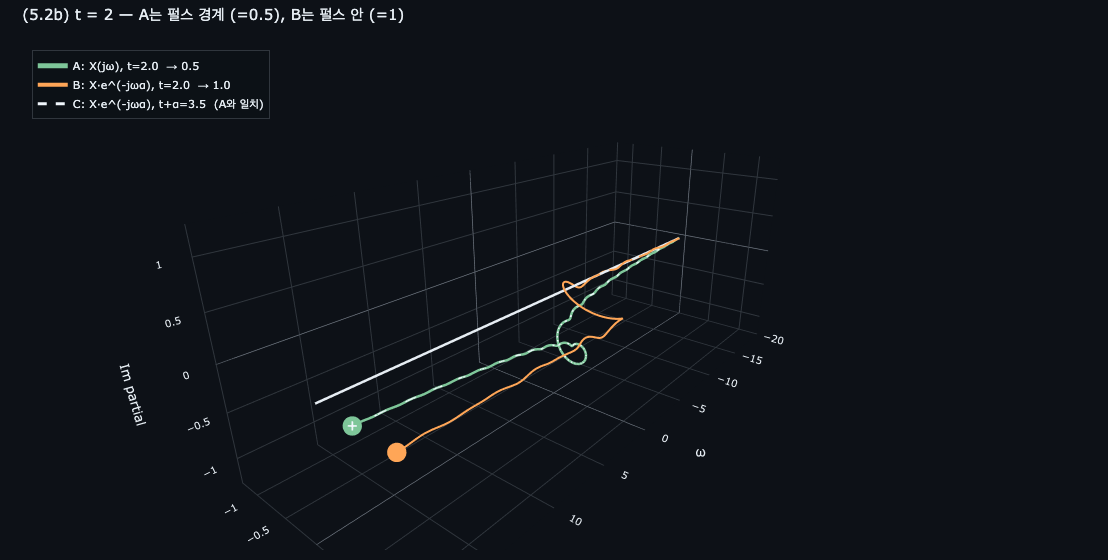

In [37]:
# 케이스 2: t=2 — 펄스 경계 (A=0.5, B=1, 다른 끝점)
fig_t2 = make_three_trails_3d(t_value=2.0,
    label='(5.2b) t = 2 — A는 펄스 경계 (=0.5), B는 펄스 안 (=1)')
fig_t2.show()

**(5.2b) t=2**: A는 펄스 경계라 끝점 ≈ 0.5, B는 t-α=0.5에서 펄스 안 → 끝점 ≈ 1. **두 trail이 다른 점에 도달**. C는 t+α=3.5에서 펄스 경계라 A와 같은 0.5에서 만남 — 시각적으로도 A 위에 정확히 덧칠된다.

[(5.2c) t = 3 — A는 펄스 외부 (=0), B는 펄스 안 (=1)]  t = 3.0
  Trail A 끝점 (X, t):                  +0.0135-0.0000j    target rect_W(t)   = 0.0
  Trail B 끝점 (X·e^(-jωα), t):         +1.0379+0.0000j    target rect_W(t-α) = 1.0
  Trail C 끝점 (X·e^(-jωα), t+α):       +0.0135-0.0000j    target rect_W(t)   = 0.0
  cum_A vs cum_C max diff = 1.84e-16



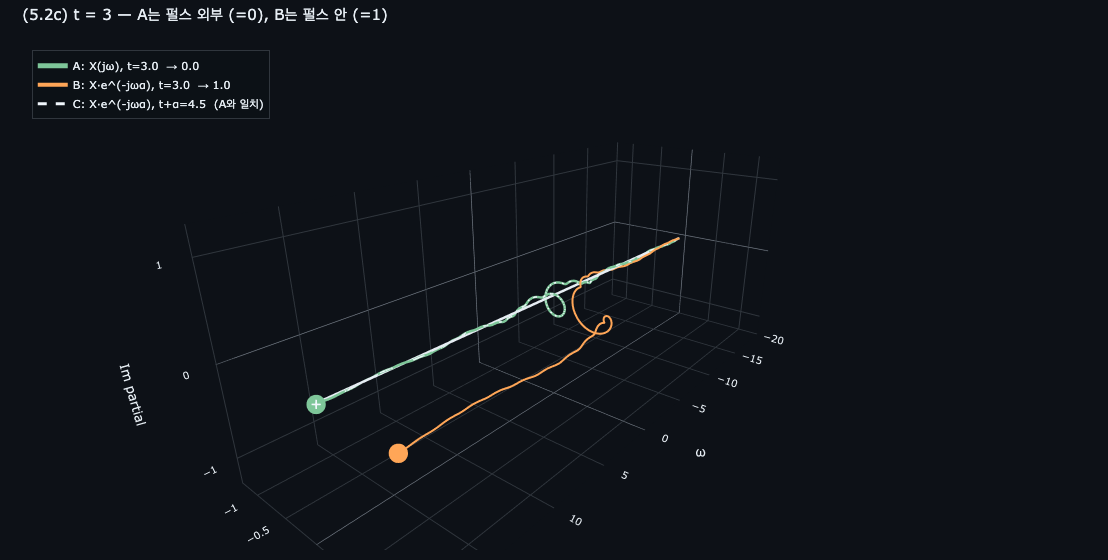

In [38]:
# 케이스 3: t=3 — 펄스 외부 (A=0, B=1, 정반대)
fig_t3 = make_three_trails_3d(t_value=3.0,
    label='(5.2c) t = 3 — A는 펄스 외부 (=0), B는 펄스 안 (=1)')
fig_t3.show()

**(5.2c) t=3**: 가장 강력한 메시지 — A는 펄스 *밖*이라 끝점 ≈ 0, B는 t-α=1.5라 펄스 안 → 끝점 ≈ 1. **두 trail이 정반대 위치에 도달**. C는 t+α=4.5에서 외부라 A와 같은 0에서 만남.

세 케이스를 종합하면 linear phase의 효과가 명확히 보인다 — *같은 t에서 보면 A와 B는 ω 따라 다른 회전을 누적하다 다른 끝점에 도달하지만, t를 α만큼 보정하면 두 적분이 항상 정확히 같다*. 끝점이 같든 다르든, A vs C의 동등성은 모든 t에서 보존된다 (time shift property).

**평행이동된 신호 전체 검증** — `X·e^(-jωα)`를 여러 t_fix에서 역변환해 평행이동된 rect를 복원:

In [39]:
# X_o_shift는 5.2 셀에서 X_3d_shift와 별개로 inverse 정확도용 데이터.
# Phase 4에서 만든 om_o, X_o (paired_by_abs 정렬)를 재사용.
X_o_shift = X_o * np.exp(-1j * om_o * ALPHA)

test_t_fix = [-1.5, -0.5, 0.0, 1.5, 3.0, 3.5, 4.5]

print('  t_fix     rect_W(t_fix - α)    recovered           |error|')
print('  ──────────────────────────────────────────────────────────')
for t_fix in test_t_fix:
    arrows = X_o_shift * np.exp(1j * om_o * t_fix) * domega_inv / (2 * np.pi)
    rec = complex(np.sum(arrows))
    arg = t_fix - ALPHA
    if abs(abs(arg) - W) < 1e-9:
        a = 0.5
    elif abs(arg) < W:
        a = 1.0
    else:
        a = 0.0
    err = abs(rec.real - a)
    print(f'  {t_fix:+5.2f}     {a:.3f}              ({rec.real:+.4f},{rec.imag:+.4f})    {err:.2e}')

  t_fix     rect_W(t_fix - α)    recovered           |error|
  ──────────────────────────────────────────────────────────
  -1.50     0.000              (-0.0000,+0.0000)    1.31e-05
  -0.50     0.500              (+0.4982,+0.0000)    1.84e-03
  +0.00     1.000              (+1.0157,+0.0000)    1.57e-02
  +1.50     1.000              (+1.0098,+0.0000)    9.80e-03
  +3.00     1.000              (+1.0157,-0.0000)    1.57e-02
  +3.50     0.500              (+0.4982,-0.0000)    1.84e-03
  +4.50     0.000              (-0.0000,-0.0000)    1.31e-05


**결과 해석**:
- 펄스 내부 (`t_fix - α ∈ (-W, W)` = `t_fix ∈ (-0.5, 3.5)`): recovered ≈ 1
- 경계 (`t_fix = -0.5` 또는 `3.5`): recovered ≈ 0.5
- 외부: recovered ≈ 0
- 모든 허수부 ≈ 0 (실수 신호 cancel)

평행이동된 rect가 정확히 복원됨. linear phase가 곧 time shift라는 property가 수치로도 검증.

## 정리

이 노트북에서 `rect_W(t)`(W=2)를 *순방향과 역방향* 양쪽으로 분석했다.

| Phase | 메시지 |
|---|---|
| 1 | `sin(ωW)` — 단위원 위 호의 chord 길이 |
| 2 | `1/ω` — 같은 호를 만든 시간이 ω에 반비례 |
| 3 | 두 항이 합쳐져 `2sin(ωW)/ω` = sinc. SpectrumPlot으로 전체 모양 |
| 4 | 역변환: sinc를 다시 rect로. 펄스 내부/경계/외부에서 trail 모양이 어떻게 다른지 |
| 5 | Linear phase × X(jω) = 평행이동된 신호. 두 적분이 *같은 화살표 시퀀스*임을 그림으로 증명 |

다른 노트북:
- [`01_intro.ipynb`](./01_intro.ipynb) — 복소 정현파/cos/sin/감쇠/timeshift의 winding 직관 (Mode A 정성적 메시지).
- [`02_inverse.ipynb`](./02_inverse.ipynb) — 가우시안·causal exp·two-sided exp 등 *다양한 신호*의 역변환 메커니즘. paired_by_abs 정렬과 켤레 cancel.